# Movie Ratings by Genre: Exploratory Analysis

## Motivation

This notebook examines how movie ratings vary across genres. Before comparing ratings, we must first understand the genre representation in `movie.csv`:

1. How many genre labels are present?
2. Does each movie have exactly one genre?
3. How common are single-genre and multi-genre movies?
4. Which genres are most and least represented?
5. How do rating volume, mean rating, and high-rating rate vary by genre?

A high rating is defined consistently with the first notebook:

$$
Y = \mathbb{1}(\text{rating} \ge 4).
$$

This is an exploratory, descriptive analysis. It does not build a model or create predictive features.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path("..") / "data" / "raw"
MOVIES_PATH = DATA_DIR / "movie.csv"
RATINGS_PATH = DATA_DIR / "rating.csv"

MOVIE_DTYPES = {
    "movieId": "int32",
    "title": "string",
    "genres": "string",
}

movies = pd.read_csv(MOVIES_PATH, dtype=MOVIE_DTYPES)

print(f"Movies: {len(movies):,}")
print("Columns:", movies.columns.tolist())
print("\nDtypes:")
print(movies.dtypes)
print("\nMissing values:")
print(movies.isna().sum())
print(f"Duplicate movieId values: {movies['movieId'].duplicated().sum():,}")

Movies: 27,278
Columns: ['movieId', 'title', 'genres']

Dtypes:
movieId     int32
title      string
genres     string
dtype: object

Missing values:
movieId    0
title      0
genres     0
dtype: int64
Duplicate movieId values: 0


## 1. Genre representation

The `genres` field is not a single categorical variable. MovieLens stores one or more labels separated by `|`, for example:

```text
Adventure|Animation|Children|Comedy|Fantasy
```

We split this field into a list, count labels per movie, and create an exploded movie–genre table. The placeholder `(no genres listed)` is kept separate from real genres.

In [2]:
NO_GENRE_LABEL = "(no genres listed)"

movies["genre_list"] = movies["genres"].str.split("|")
movies["n_genres"] = movies["genre_list"].str.len().astype("int8")

movie_genres = (
    movies[["movieId", "title", "genre_list"]]
    .explode("genre_list")
    .rename(columns={"genre_list": "genre"})
)

all_labels = sorted(movie_genres["genre"].dropna().unique())
real_genres = [genre for genre in all_labels if genre != NO_GENRE_LABEL]
no_genre_count = int((movies["genres"] == NO_GENRE_LABEL).sum())

print(f"Unique labels including placeholder: {len(all_labels)}")
print(f"Actual genre labels:                 {len(real_genres)}")
print(f"Raw genre combinations:              {movies['genres'].nunique():,}")
print(f"Movies with no listed genre:         {no_genre_count:,}")
print("\nGenre labels:")
print(", ".join(real_genres))

Unique labels including placeholder: 20
Actual genre labels:                 19
Raw genre combinations:              1,342
Movies with no listed genre:         246

Genre labels:
Action, Adventure, Animation, Children, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, IMAX, Musical, Mystery, Romance, Sci-Fi, Thriller, War, Western


## 2. Are genres unitary?

A movie is **single-genre** when it has one listed label and **multi-genre** when it has two or more. Because `(no genres listed)` is a placeholder rather than a genre, we report it separately.

In [3]:
has_known_genre = movies["genres"] != NO_GENRE_LABEL
single_genre = has_known_genre & (movies["n_genres"] == 1)
multi_genre = has_known_genre & (movies["n_genres"] > 1)

structure_summary = pd.Series(
    {
        "Single-genre movies": int(single_genre.sum()),
        "Multi-genre movies": int(multi_genre.sum()),
        "No genre listed": no_genre_count,
    },
    name="n_movies",
).to_frame()
structure_summary["percentage"] = 100 * structure_summary["n_movies"] / len(movies)

print(structure_summary.to_string(float_format=lambda value: f"{value:.2f}"))

print("\nNumber of listed labels per movie (placeholder included as one label):")
genre_count_distribution = movies["n_genres"].value_counts().sort_index()
print(genre_count_distribution.to_string())

                     n_movies  percentage
Single-genre movies     10583       38.80
Multi-genre movies      16449       60.30
No genre listed           246        0.90

Number of listed labels per movie (placeholder included as one label):
n_genres
1     10829
2      8809
3      5330
4      1724
5       477
6        83
7        20
8         5
10        1


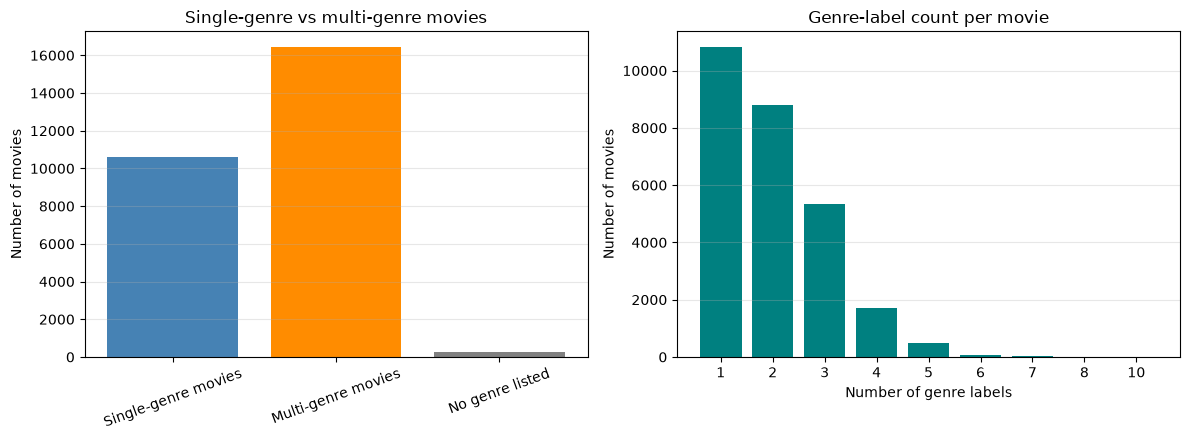

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(
    structure_summary.index,
    structure_summary["n_movies"],
    color=["steelblue", "darkorange", "gray"],
)
axes[0].set_ylabel("Number of movies")
axes[0].set_title("Single-genre vs multi-genre movies")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(
    genre_count_distribution.index.astype(str),
    genre_count_distribution.values,
    color="teal",
)
axes[1].set_xlabel("Number of genre labels")
axes[1].set_ylabel("Number of movies")
axes[1].set_title("Genre-label count per movie")
axes[1].grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

### Initial finding

MovieLens contains 19 actual genre labels plus the `(no genres listed)` placeholder. Genres are **not unitary**: 16,449 movies (60.30%) have multiple genre labels, 10,583 (38.80%) have exactly one known genre, and 246 (0.90%) have no listed genre. One movie has as many as 10 labels.

Genre must therefore be treated as a multi-label field rather than a conventional single-category column. An action-comedy contributes to both `Action` and `Comedy`, so genre groups overlap and their percentages do not sum to 100%.

## 3. Movie coverage by genre

Because genres overlap, percentages across genres do not sum to 100%. Each percentage answers: “What share of movies has this genre label?” The placeholder is excluded from the genre ranking.

             n_movies  pct_of_movies
genre                               
Drama           13344          48.92
Comedy           8374          30.70
Thriller         4178          15.32
Romance          4127          15.13
Action           3520          12.90
Crime            2939          10.77
Horror           2611           9.57
Documentary      2471           9.06
Adventure        2329           8.54
Sci-Fi           1743           6.39
Mystery          1514           5.55
Fantasy          1412           5.18
War              1194           4.38
Children         1139           4.18
Musical          1036           3.80
Animation        1027           3.76
Western           676           2.48
Film-Noir         330           1.21
IMAX              196           0.72


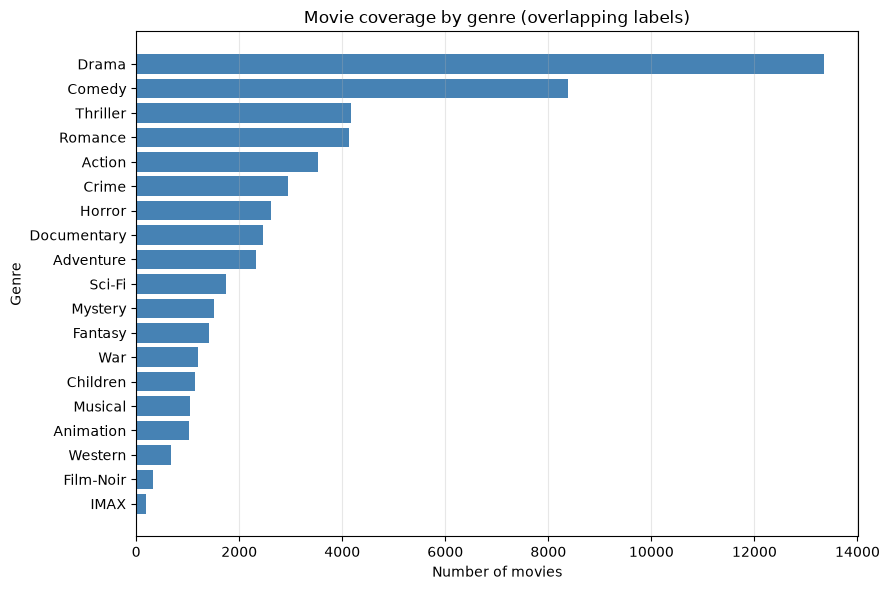

In [5]:
genre_movie_counts = (
    movie_genres.loc[movie_genres["genre"] != NO_GENRE_LABEL]
    .groupby("genre")
    .agg(n_movies=("movieId", "nunique"))
    .sort_values("n_movies", ascending=False)
)
genre_movie_counts["pct_of_movies"] = 100 * genre_movie_counts["n_movies"] / len(movies)

print(genre_movie_counts.to_string(float_format=lambda value: f"{value:.2f}"))

fig, ax = plt.subplots(figsize=(9, 6))
plot_data = genre_movie_counts.sort_values("n_movies")
ax.barh(plot_data.index, plot_data["n_movies"], color="steelblue")
ax.set_xlabel("Number of movies")
ax.set_ylabel("Genre")
ax.set_title("Movie coverage by genre (overlapping labels)")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

### Catalog coverage finding

Genre representation is highly uneven. `Drama` appears on 13,344 movies (48.92% of the catalog) and `Comedy` on 8,374 (30.70%). At the other extreme, `Film-Noir` appears on 330 movies (1.21%) and `IMAX` on 196 (0.72%). These are overlapping memberships, so the large share of drama does not mean that half of the catalog consists of drama-only movies.

## 4. Rating data and memory-efficient aggregation

The ratings table has approximately 20 million rows. Joining every rating directly to the exploded genre table would multiply rows for multi-genre movies. Instead, we first aggregate ratings by `movieId`, producing one row per rated movie, and only then join to genre membership.

This preserves exact genre-level rating totals while substantially reducing memory use. Because memberships overlap, one rating is attributed to every listed genre of its movie; genre rating counts therefore should not be summed across rows.

In [6]:
RATING_DTYPES = {
    "movieId": "int32",
    "rating": "float32",
}

ratings = pd.read_csv(
    RATINGS_PATH,
    usecols=["movieId", "rating"],
    dtype=RATING_DTYPES,
)
ratings["high_rating"] = (ratings["rating"] >= 4).astype("int8")

movie_rating_stats = (
    ratings.groupby("movieId", sort=False)
    .agg(
        n_ratings=("rating", "size"),
        rating_sum=("rating", "sum"),
        high_rating_count=("high_rating", "sum"),
        mean_rating=("rating", "mean"),
        high_rating_rate=("high_rating", "mean"),
    )
)

overall_mean_rating = float(ratings["rating"].mean())
overall_high_rating_rate = float(ratings["high_rating"].mean())

print(f"Ratings loaded:         {len(ratings):,}")
print(f"Rated movies:           {len(movie_rating_stats):,}")
print(f"Catalog movies:         {len(movies):,}")
print(f"Catalog movies unrated: {len(movies) - len(movie_rating_stats):,}")
print(f"Overall mean rating:    {overall_mean_rating:.3f}")
print(f"Overall high-rate:      {overall_high_rating_rate:.3%}")

# The full rating-level table is no longer needed after movie aggregation.
del ratings

Ratings loaded:         20,000,263
Rated movies:           26,744
Catalog movies:         27,278
Catalog movies unrated: 534
Overall mean rating:    3.526
Overall high-rate:      49.976%


## 5. Rating outcomes by genre

Two perspectives are useful:

- **Rating-weighted mean:** describes the average rating event associated with a genre. Popular movies receive more weight.
- **Median movie mean:** describes the typical rated movie in a genre after giving each movie equal weight.

The first is most directly connected to the future rating-level target; the second helps reveal whether blockbuster popularity dominates the result.

In [7]:
genre_movie_ratings = (
    movie_genres.loc[movie_genres["genre"] != NO_GENRE_LABEL]
    .merge(movie_rating_stats, left_on="movieId", right_index=True, how="left", validate="many_to_one")
)

# Aggregate sums to recover exact rating-event-weighted metrics.
genre_rating_summary = (
    genre_movie_ratings.groupby("genre")
    .agg(
        n_catalog_movies=("movieId", "nunique"),
        n_rated_movies=("n_ratings", "count"),
        n_ratings=("n_ratings", "sum"),
        rating_sum=("rating_sum", "sum"),
        high_rating_count=("high_rating_count", "sum"),
        median_movie_mean=("mean_rating", "median"),
    )
)
genre_rating_summary["mean_rating"] = (
    genre_rating_summary["rating_sum"] / genre_rating_summary["n_ratings"]
)
genre_rating_summary["high_rating_rate"] = (
    genre_rating_summary["high_rating_count"] / genre_rating_summary["n_ratings"]
)
genre_rating_summary["catalog_rating_coverage"] = (
    genre_rating_summary["n_rated_movies"] / genre_rating_summary["n_catalog_movies"]
)

genre_rating_summary = genre_rating_summary.sort_values("mean_rating", ascending=False)
summary_columns = [
    "n_catalog_movies",
    "n_rated_movies",
    "n_ratings",
    "mean_rating",
    "high_rating_rate",
    "median_movie_mean",
    "catalog_rating_coverage",
]
print(
    genre_rating_summary[summary_columns].to_string(
        formatters={
            "n_ratings": lambda value: f"{value:,.0f}",
            "mean_rating": lambda value: f"{value:.3f}",
            "high_rating_rate": lambda value: f"{value:.2%}",
            "median_movie_mean": lambda value: f"{value:.3f}",
            "catalog_rating_coverage": lambda value: f"{value:.2%}",
        }
    )
)

             n_catalog_movies  n_rated_movies n_ratings mean_rating high_rating_rate median_movie_mean catalog_rating_coverage
genre                                                                                                                         
Film-Noir                 330             322   216,689       3.965           69.66%             3.488                  97.58%
War                      1194            1173 1,048,618       3.810           62.05%             3.417                  98.24%
Documentary              2471            2391   244,619       3.740           60.13%             3.500                  96.76%
Crime                    2939            2889 3,298,335       3.675           55.92%             3.220                  98.30%
Drama                   13344           13062 8,857,853       3.674           56.01%             3.341                  97.89%
Mystery                  1514            1489 1,557,282       3.664           55.66%             3.174         

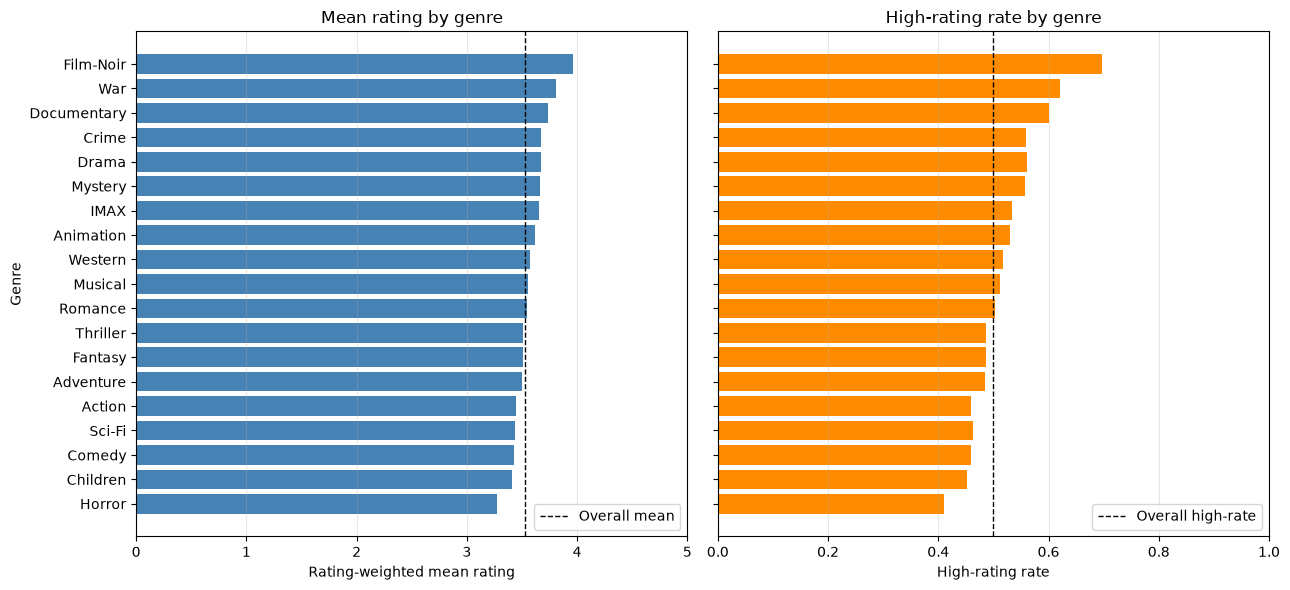

In [8]:
plot_order = genre_rating_summary.sort_values("mean_rating")

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

axes[0].barh(plot_order.index, plot_order["mean_rating"], color="steelblue")
axes[0].axvline(
    overall_mean_rating,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Overall mean",
)
axes[0].set_xlabel("Rating-weighted mean rating")
axes[0].set_ylabel("Genre")
axes[0].set_title("Mean rating by genre")
axes[0].set_xlim(0, 5)
axes[0].legend()
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh(plot_order.index, plot_order["high_rating_rate"], color="darkorange")
axes[1].axvline(
    overall_high_rating_rate,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Overall high-rate",
)
axes[1].set_xlabel("High-rating rate")
axes[1].set_title("High-rating rate by genre")
axes[1].set_xlim(0, 1)
axes[1].legend()
axes[1].grid(axis="x", alpha=0.3)

fig.tight_layout()
plt.show()

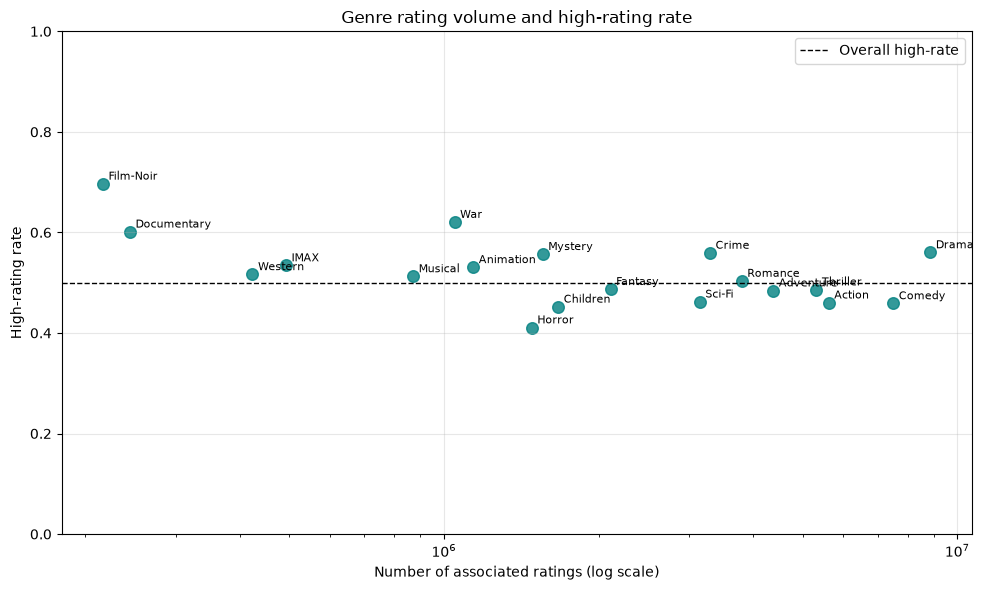

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    genre_rating_summary["n_ratings"],
    genre_rating_summary["high_rating_rate"],
    s=70,
    alpha=0.8,
    color="teal",
)

for genre, row in genre_rating_summary.iterrows():
    ax.annotate(
        genre,
        (row["n_ratings"], row["high_rating_rate"]),
        xytext=(4, 3),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(
    overall_high_rating_rate,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Overall high-rate",
)
ax.set_xscale("log")
ax.set_xlabel("Number of associated ratings (log scale)")
ax.set_ylabel("High-rating rate")
ax.set_title("Genre rating volume and high-rating rate")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Rating findings

Rating outcomes differ meaningfully across overlapping genre groups. `Film-Noir` has the highest rating-weighted mean (3.965) and high-rating rate (69.66%), followed by `War` (3.810; 62.05%) and `Documentary` (3.740; 60.13%). `Horror` has the lowest values (3.277; 41.07%), followed by `Children` (3.408; 45.20%), `Comedy` (3.426; 45.86%), and `Sci-Fi` (3.437; 46.21%). The overall dataset mean is 3.526 and the overall high-rating rate is 49.98%.

Support varies substantially: `Drama` is associated with 8.86 million ratings, while `Film-Noir` has about 217 thousand and `Documentary` about 245 thousand. All genre estimates have considerable rating support, but comparisons remain influenced by overlapping labels and by which movies become popular within each genre. The lower median movie means relative to rating-weighted means also show that frequently rated movies tend to receive more favorable ratings than the typical catalog movie.

## 6. Statistical and interpretive cautions

Genre-level differences are descriptive associations, not causal genre effects:

- Genres overlap, so the groups are neither independent nor mutually exclusive.
- A genre's result is influenced by its particular movies, users, release periods, and popularity.
- Rating-weighted metrics give popular movies more influence.
- Genres with fewer movies or ratings have less stable estimates.
- A higher genre mean does not imply that changing a movie's label would change its rating.

These summaries are useful for understanding the dataset and motivating later questions, but they should not yet be used as model features or interpreted as user preference drift.

# Conclusions

### Q1. How many genres are present?

There are **19 actual genre labels**. A twentieth value, `(no genres listed)`, is a placeholder used by 246 movies and should not be treated as a genre.

### Q2. Are movie genres unitary?

**No.** Genre is a multi-label attribute: 60.30% of movies have two or more labels, compared with 38.80% that have exactly one known genre. Any later genre analysis must preserve this overlap rather than forcing each movie into one category.

### Q3. Which genres dominate the catalog?

`Drama` is the broadest label, covering 48.92% of movies, followed by `Comedy` at 30.70%. `Film-Noir` and `IMAX` are the least common labels. Because memberships overlap, these percentages describe label coverage and cannot be added together.

### Q4. Do rating outcomes vary by genre?

**Yes, descriptively.** `Film-Noir`, `War`, and `Documentary` have the highest rating-weighted outcomes, while `Horror`, `Children`, `Comedy`, and `Sci-Fi` fall below the overall baseline. The range in high-rating rates—from 41.07% for `Horror` to 69.66% for `Film-Noir`—is large enough to motivate deeper analysis.

### Q5. What can we conclude from these differences?

Genre membership contains meaningful descriptive signal, but the current comparisons are not causal and do not isolate a pure genre effect. Genres overlap, users self-select movies, rating volume is uneven, and popular movies receive more weight. A useful next analysis would compare users' genre-specific rating behavior while controlling for user-level generosity and respecting chronological order.